## Credit Card Fraud Detection

In this project you will predict fraudulent credit card transactions with the help of Machine learning models. Please import the following libraries to get started.

In [1]:
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
%matplotlib inline
import seaborn as sns

from sklearn import metrics
from sklearn import preprocessing

## Exploratory data analysis

In [2]:
df = pd.read_csv('creditcard.csv')
df.head()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


In [3]:
#observe the different feature type present in the data

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 284807 entries, 0 to 284806
Data columns (total 31 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   Time    284807 non-null  float64
 1   V1      284807 non-null  float64
 2   V2      284807 non-null  float64
 3   V3      284807 non-null  float64
 4   V4      284807 non-null  float64
 5   V5      284807 non-null  float64
 6   V6      284807 non-null  float64
 7   V7      284807 non-null  float64
 8   V8      284807 non-null  float64
 9   V9      284807 non-null  float64
 10  V10     284807 non-null  float64
 11  V11     284807 non-null  float64
 12  V12     284807 non-null  float64
 13  V13     284807 non-null  float64
 14  V14     284807 non-null  float64
 15  V15     284807 non-null  float64
 16  V16     284807 non-null  float64
 17  V17     284807 non-null  float64
 18  V18     284807 non-null  float64
 19  V19     284807 non-null  float64
 20  V20     284807 non-null  float64
 21  V21     28

Here we will observe the distribution of our classes

In [4]:
classes=df['Class'].value_counts()
normal_share=classes[0]/df['Class'].count()*100
fraud_share=classes[1]/df['Class'].count()*100

In [5]:
normal_share

99.82725143693798

In [6]:
fraud_share

0.1727485630620034

<BarContainer object of 2 artists>

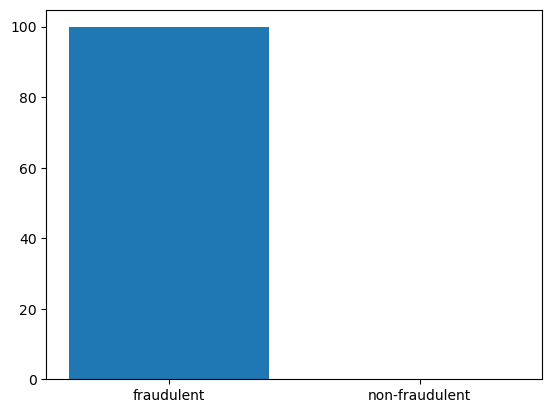

In [7]:
# Create a bar plot for the number and percentage of fraudulent vs non-fraudulent transcations
plt.bar(['fraudulent', 'non-fraudulent'], [normal_share, fraud_share])


We can see that the number of fraudulent transctions is negligible compared to the non-fraudulent ones.

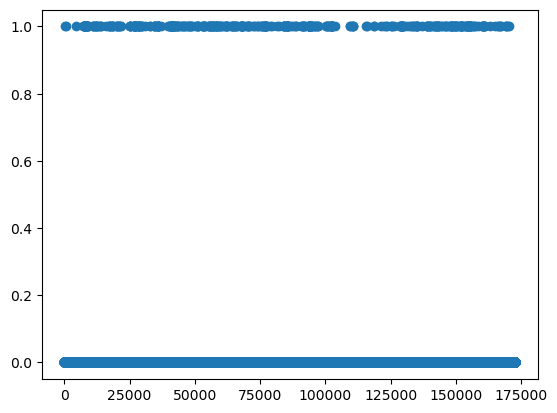

In [8]:
# Create a scatter plot to observe the distribution of classes with time
plt.scatter(df['Time'], df['Class'])

We can observe that the fraudulent transactions are also uniformly spread over the given time period, so this variable is not important from the point of analysis. 

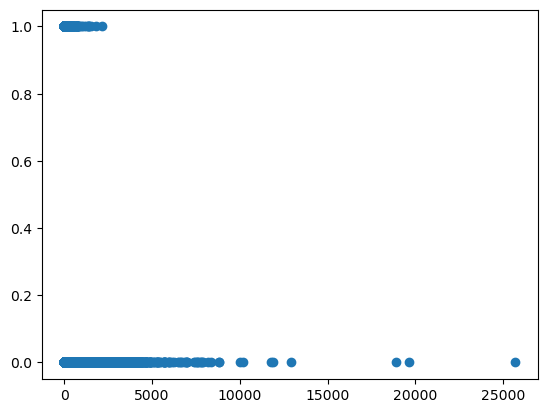

In [9]:
# Create a scatter plot to observe the distribution of classes with Amount
plt.scatter(df['Amount'], df['Class'])

We can observe that the fraudulent transactions are done for a limited amount of money in the lower bracket.

So, let us drop both time and amount columns as they will contribute any important info to our model.

In [10]:
# Drop unnecessary columns
df.drop(['Time', 'Amount'], axis = 1, inplace = True)
df.head()

,V1,V2,V3,V4,V5,V6,V7,V8,V9,V10,...,V20,V21,V22,V23,V24,V25,V26,V27,V28,Class
0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,0.090794,...,0.251412,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,0
1,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,-0.166974,...,-0.069083,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,0
2,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,0.207643,...,0.524980,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,0
3,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,-0.054952,...,-0.208038,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,0
4,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,0.753074,...,0.408542,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,0


### Splitting the data into train & test data

In [11]:
y= df.pop('Class')
X= df

In [12]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

##### Preserve X_test & y_test to evaluate on the test data once you build the model

In [13]:
print(np.sum(y))
print(np.sum(y_train))
print(np.sum(y_test))

492
394
98


### Plotting the distribution of a variable

In [14]:
columns = X_train.columns

In [15]:
columns

Index(['V1', 'V2', 'V3', 'V4', 'V5', 'V6', 'V7', 'V8', 'V9', 'V10', 'V11',
       'V12', 'V13', 'V14', 'V15', 'V16', 'V17', 'V18', 'V19', 'V20', 'V21',
       'V22', 'V23', 'V24', 'V25', 'V26', 'V27', 'V28'],
      dtype='object')

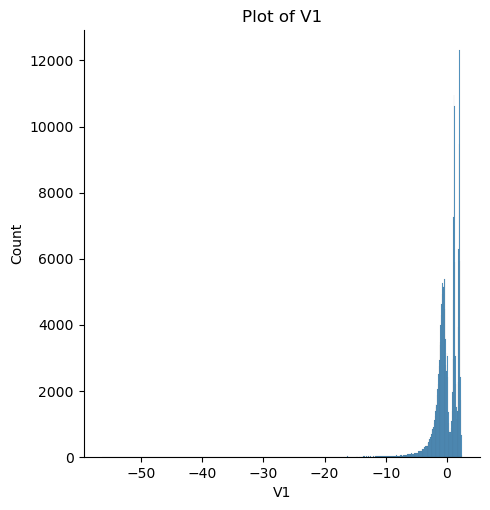

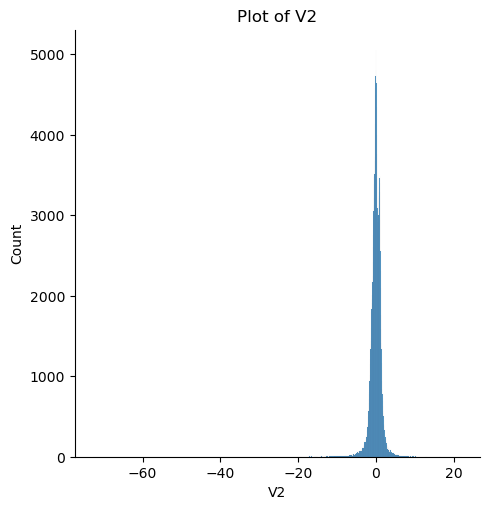

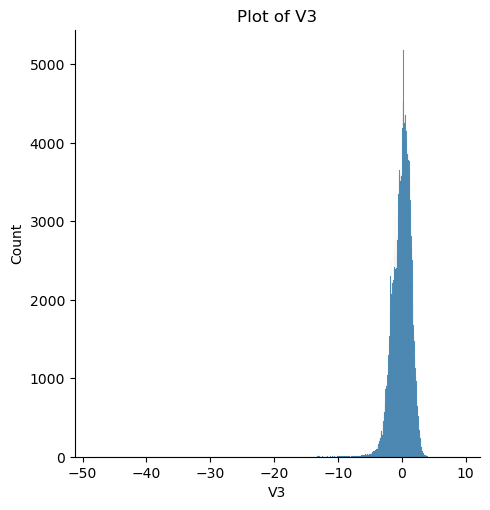

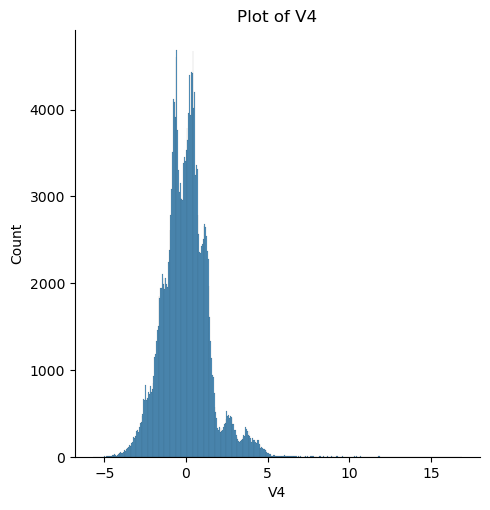

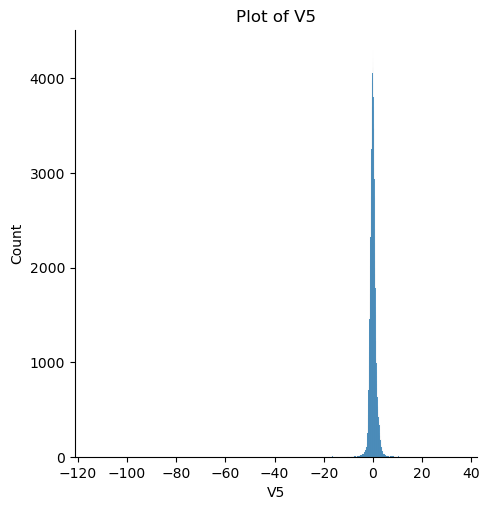

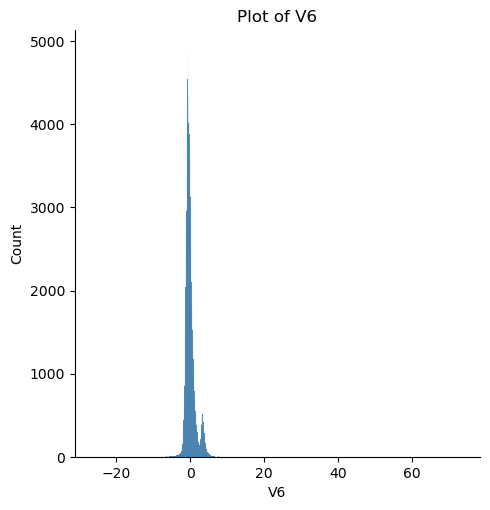

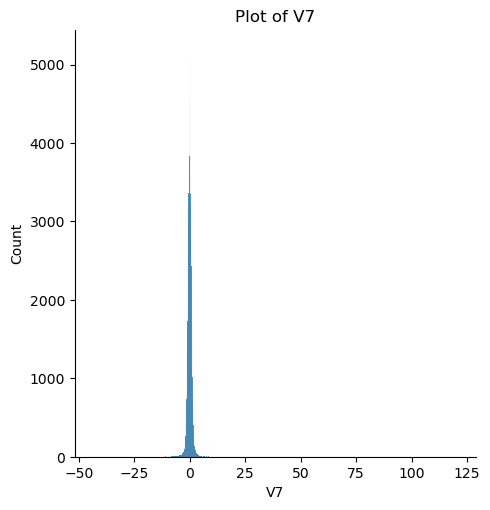

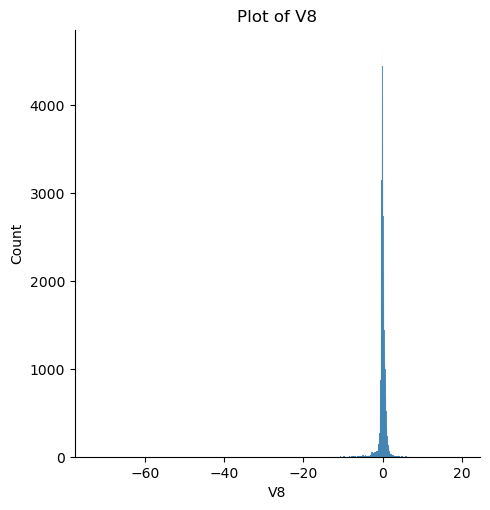

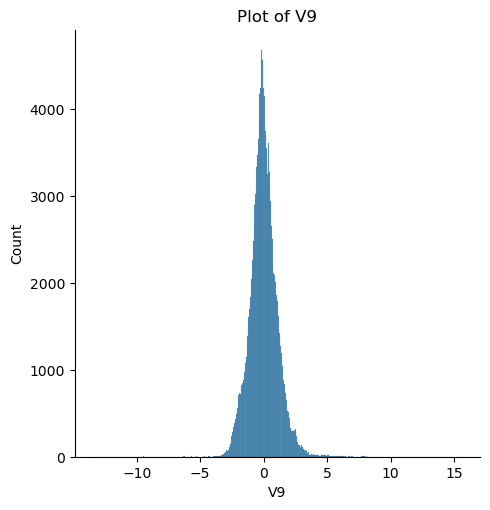

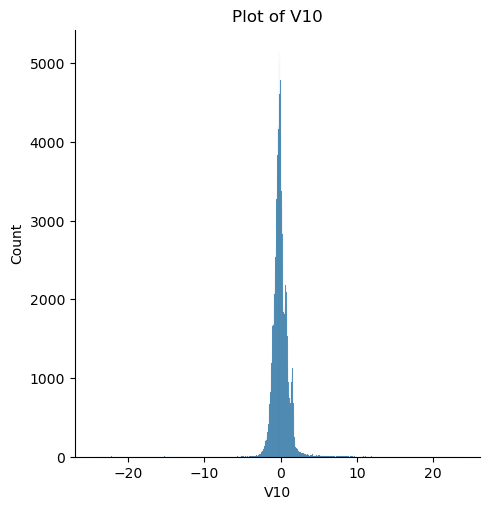

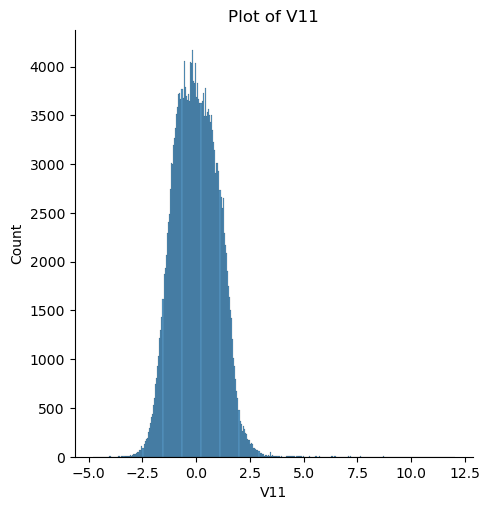

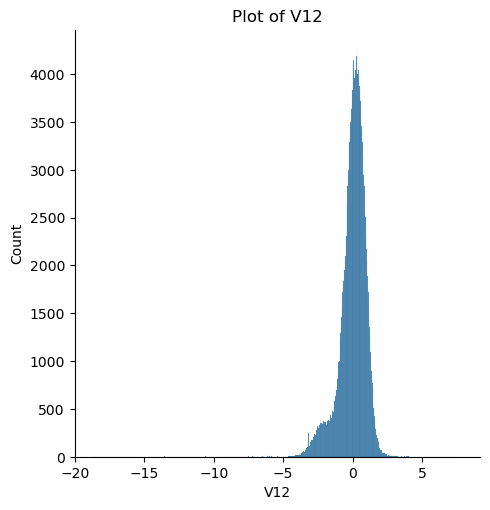

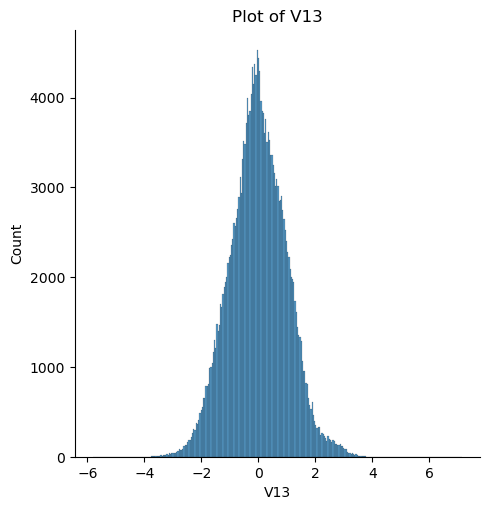

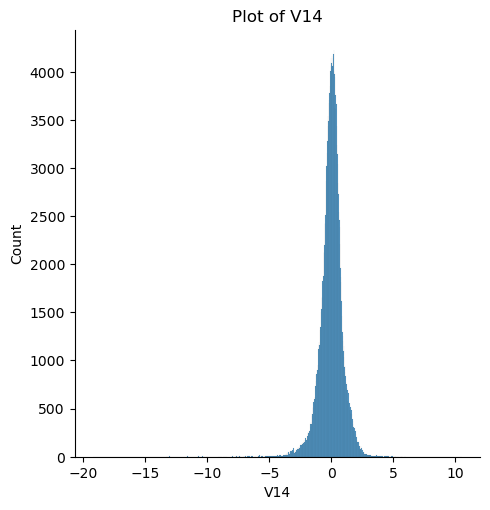

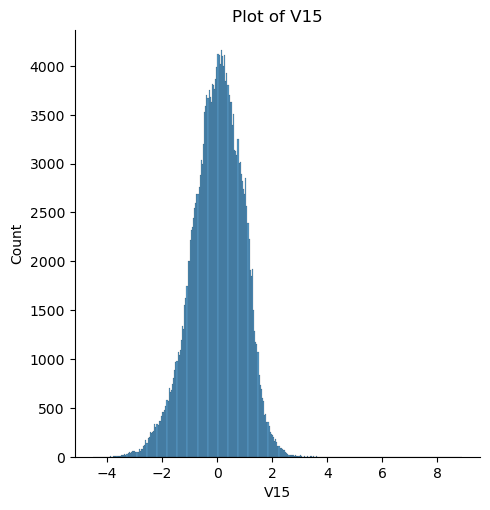

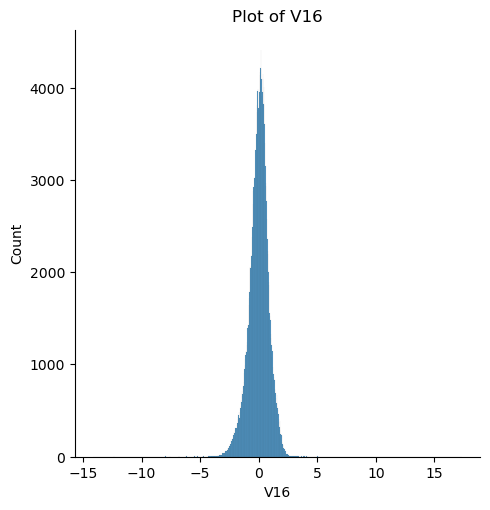

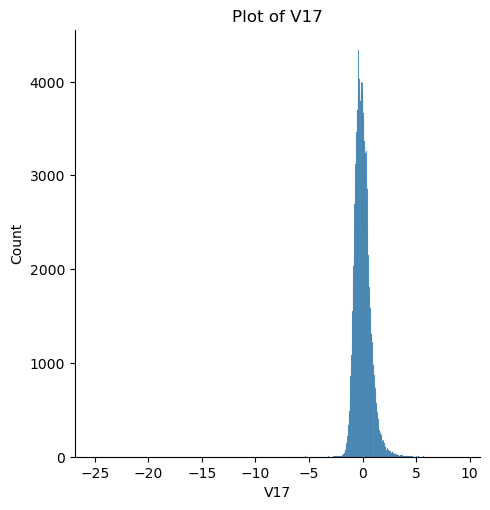

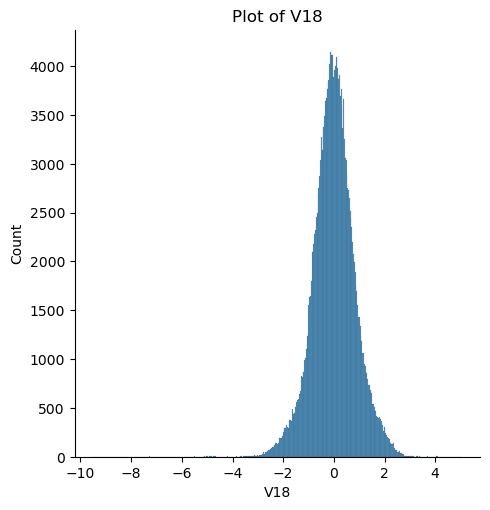

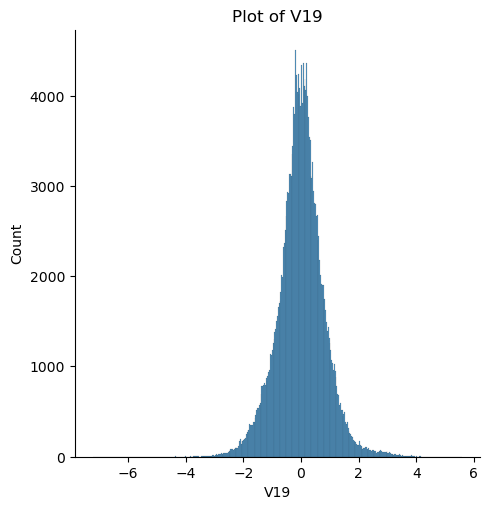

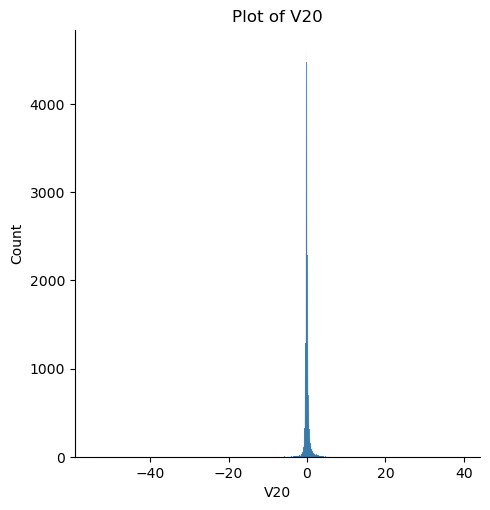

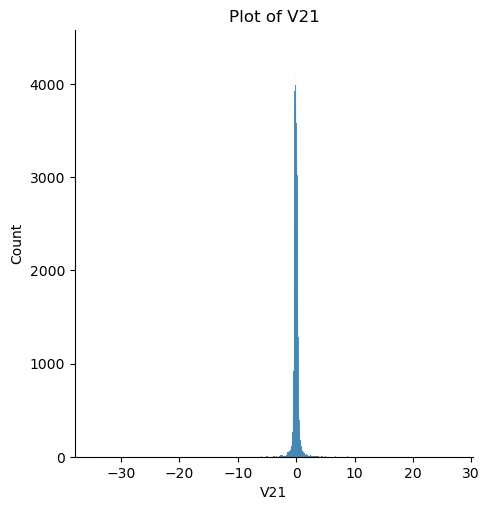

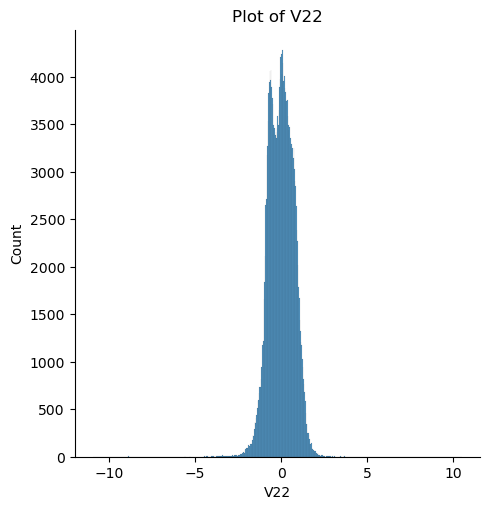

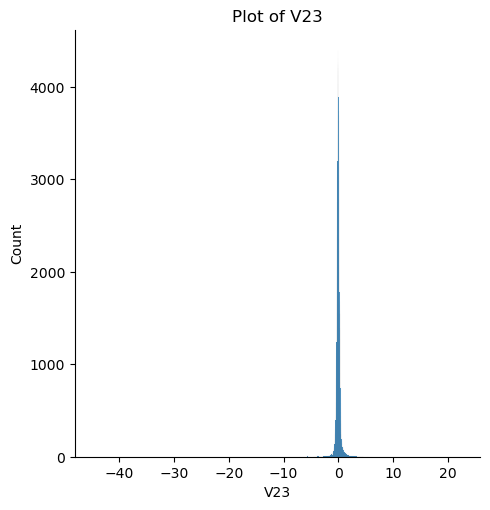

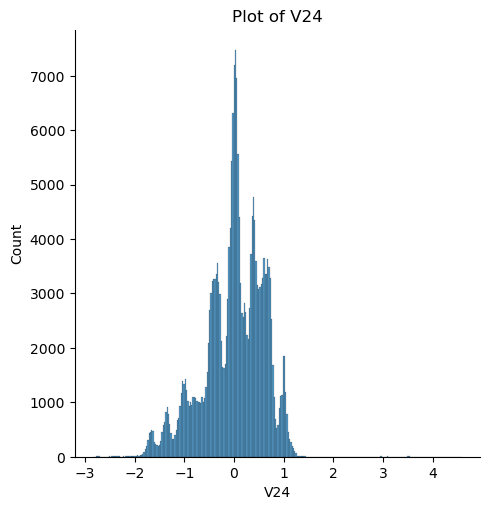

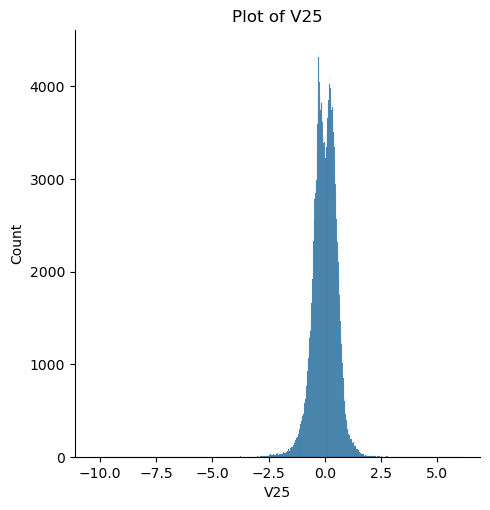

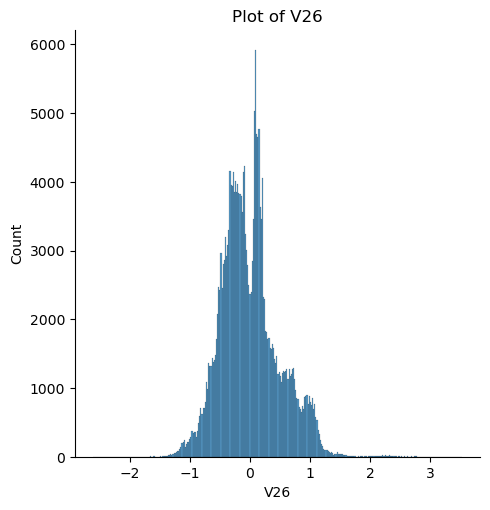

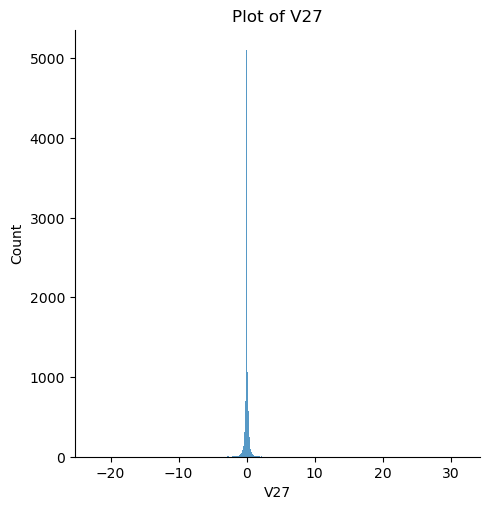

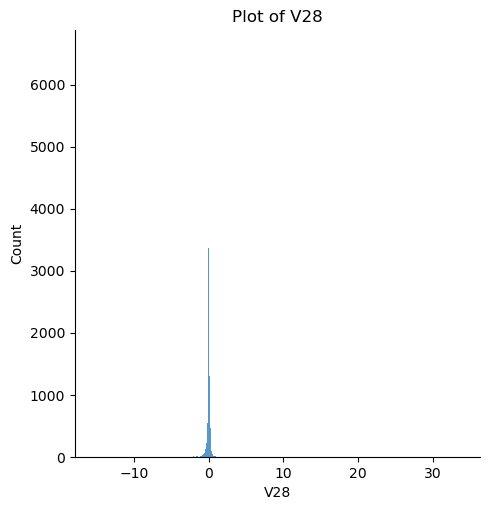

In [16]:
# plot the histogram of a variable from the dataset to see the skewness
for column in columns:
    title = "Plot of "+column
    sns.displot(X_train[column])
    plt.title(title)
    plt.show()

As we know the data is Modified using PCA, the data is not skewed and normally distributed, which is clearly visible in the hitograms shown above.

## Model Building
- Build different models on the imbalanced dataset and see the result

#### perfom cross validation on the X_train & y_train to create:
- X_train_cv
- X_test_cv 
- y_train_cv
- y_test_cv 

### We will explore the data by building models like:
- Logistic Regression 
- KNN
- Decision Tree
- Random Forest
- XGBoost

In [19]:
from sklearn.model_selection import StratifiedKFold, GridSearchCV
from sklearn.metrics import roc_auc_score
from imblearn.over_sampling import RandomOverSampler

from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier

In [20]:
def evaluate_model(model, param_grid, X, y, model_name):
    skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
    best_auc = 0
    best_params = None
    results = []

    for fold, (train_idx, val_idx) in enumerate(skf.split(X, y)):
        X_train_cv, X_val_cv = X.iloc[train_idx], X.iloc[val_idx]
        y_train_cv, y_val_cv = y.iloc[train_idx], y.iloc[val_idx]

        grid = GridSearchCV(model, param_grid, cv=3, scoring='roc_auc')
        grid.fit(X_train_cv, y_train_cv)

        y_val_pred_proba = grid.predict_proba(X_val_cv)[:, 1]
        auc = roc_auc_score(y_val_cv, y_val_pred_proba)

        results.append({'fold': fold + 1, 'roc_auc': auc, 'best_params': grid.best_params_})

        if auc > best_auc:
            best_auc = auc
            best_params = grid.best_params_
            best_model = grid.best_estimator_

    print(f"\n📊 {model_name} Results (Original Data):")
    df = pd.DataFrame(results)
    print(df)
    print(f"🏆 Best ROC AUC: {best_auc:.4f}")
    print(f"✅ Optimal Hyperparameters: {best_params}")

    return model_name, best_auc, best_params


In [21]:
models_orig = [
    ("Logistic Regression", LogisticRegression(solver='liblinear'), {'C': [0.001, 0.01, 0.1, 1, 10, 100]}),
    ("KNN", KNeighborsClassifier(), {'n_neighbors': [3, 5, 7]}),
    ("Decision Tree", DecisionTreeClassifier(random_state=42), {'max_depth': [3, 5, 10, None]}),
    ("Random Forest", RandomForestClassifier(random_state=42), {'n_estimators': [50, 100], 'max_depth': [5, 10, None]}),
    ("XGBoost", XGBClassifier(use_label_encoder=False, eval_metric='logloss'), {'n_estimators': [50, 100], 'max_depth': [3, 5, 7]})
]

In [22]:
summary_results_orig = []

for name, model, params in models_orig:
    model_name, auc_score, best_params = evaluate_model(model, params, X_train, y_train, name)
    summary_results_orig.append({'Model': model_name, 'ROC AUC': auc_score, 'Best Params': best_params})



📊 Logistic Regression Results (Original Data):
   fold   roc_auc  best_params
0     1  0.988809  {'C': 0.01}
1     2  0.980764  {'C': 0.01}
2     3  0.967808   {'C': 0.1}
3     4  0.991335  {'C': 0.01}
4     5  0.980884  {'C': 0.01}
🏆 Best ROC AUC: 0.9913
✅ Optimal Hyperparameters: {'C': 0.01}

📊 KNN Results (Original Data):
   fold   roc_auc         best_params
0     1  0.929328  {'n_neighbors': 7}
1     2  0.904910  {'n_neighbors': 7}
2     3  0.892245  {'n_neighbors': 7}
3     4  0.936543  {'n_neighbors': 7}
4     5  0.923874  {'n_neighbors': 7}
🏆 Best ROC AUC: 0.9365
✅ Optimal Hyperparameters: {'n_neighbors': 7}

📊 Decision Tree Results (Original Data):
   fold   roc_auc       best_params
0     1  0.897268  {'max_depth': 3}
1     2  0.898599  {'max_depth': 3}
2     3  0.892231  {'max_depth': 3}
3     4  0.936517  {'max_depth': 3}
4     5  0.879574  {'max_depth': 3}
🏆 Best ROC AUC: 0.9365
✅ Optimal Hyperparameters: {'max_depth': 3}

📊 Random Forest Results (Original Data):
   fold 

C:\Users\tshar\anaconda3\Lib\site-packages\xgboost\core.py:158: UserWarning: [03:12:24] WARNING: C:\buildkite-agent\builds\buildkite-windows-cpu-autoscaling-group-i-0c55ff5f71b100e98-1\xgboost\xgboost-ci-windows\src\learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)
C:\Users\tshar\anaconda3\Lib\site-packages\xgboost\core.py:158: UserWarning: [03:12:26] WARNING: C:\buildkite-agent\builds\buildkite-windows-cpu-autoscaling-group-i-0c55ff5f71b100e98-1\xgboost\xgboost-ci-windows\src\learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)
C:\Users\tshar\anaconda3\Lib\site-packages\xgboost\core.py:158: UserWarning: [03:12:28] WARNING: C:\buildkite-agent\builds\buildkite-windows-cpu-autoscaling-group-i-0c55ff5f71b100e98-1\xgboost\xgboost-ci-windows\src\learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)
C:\Users\tshar\anaconda3\Lib\site-packages\


📊 XGBoost Results (Original Data):
   fold   roc_auc                            best_params
0     1  0.992929   {'max_depth': 3, 'n_estimators': 50}
1     2  0.979217  {'max_depth': 7, 'n_estimators': 100}
2     3  0.968224   {'max_depth': 3, 'n_estimators': 50}
3     4  0.990531  {'max_depth': 3, 'n_estimators': 100}
4     5  0.984443   {'max_depth': 3, 'n_estimators': 50}
🏆 Best ROC AUC: 0.9929
✅ Optimal Hyperparameters: {'max_depth': 3, 'n_estimators': 50}


In [23]:
summary_df_orig = pd.DataFrame(summary_results_orig)
print("\n📈 Final Comparison on Original Imbalanced Data:")
print(summary_df_orig.sort_values(by="ROC AUC", ascending=False).reset_index(drop=True))



📈 Final Comparison on Original Imbalanced Data:
                 Model   ROC AUC                             Best Params
0              XGBoost  0.992929    {'max_depth': 3, 'n_estimators': 50}
1  Logistic Regression  0.991335                             {'C': 0.01}
2        Random Forest  0.985355  {'max_depth': 10, 'n_estimators': 100}
3                  KNN  0.936543                      {'n_neighbors': 7}
4        Decision Tree  0.936517                        {'max_depth': 3}


#### Proceed with the model which shows the best result 
- Apply the best hyperparameter on the model
- Predict on the test dataset

### Based on your final comparison, XGBoost is the best-performing model with a ROC AUC of 0.992929, and the best hyperparameters are:
{'max_depth': 3, 'n_estimators': 50}

In [42]:
# Initialize the model with best hyperparameters
clf = XGBClassifier(max_depth=3, n_estimators=50, use_label_encoder=False, eval_metric='logloss')

# Train on the original training set
clf.fit(X_train, y_train)

# Predict probabilities on the test set
y_pred_proba = clf.predict_proba(X_test)[:, 1]

# Evaluate using ROC AUC
roc_auc = roc_auc_score(y_test, y_pred_proba)

print(f"ROC AUC on Test Data: {roc_auc:.6f}")

ROC AUC on Test Data: 0.977327


### Print the important features of the best model to understand the dataset
- This will not give much explanation on the already transformed dataset
- But it will help us in understanding if the dataset is not PCA transformed

Top var = 10
2nd Top var = 14
3rd Top var = 7


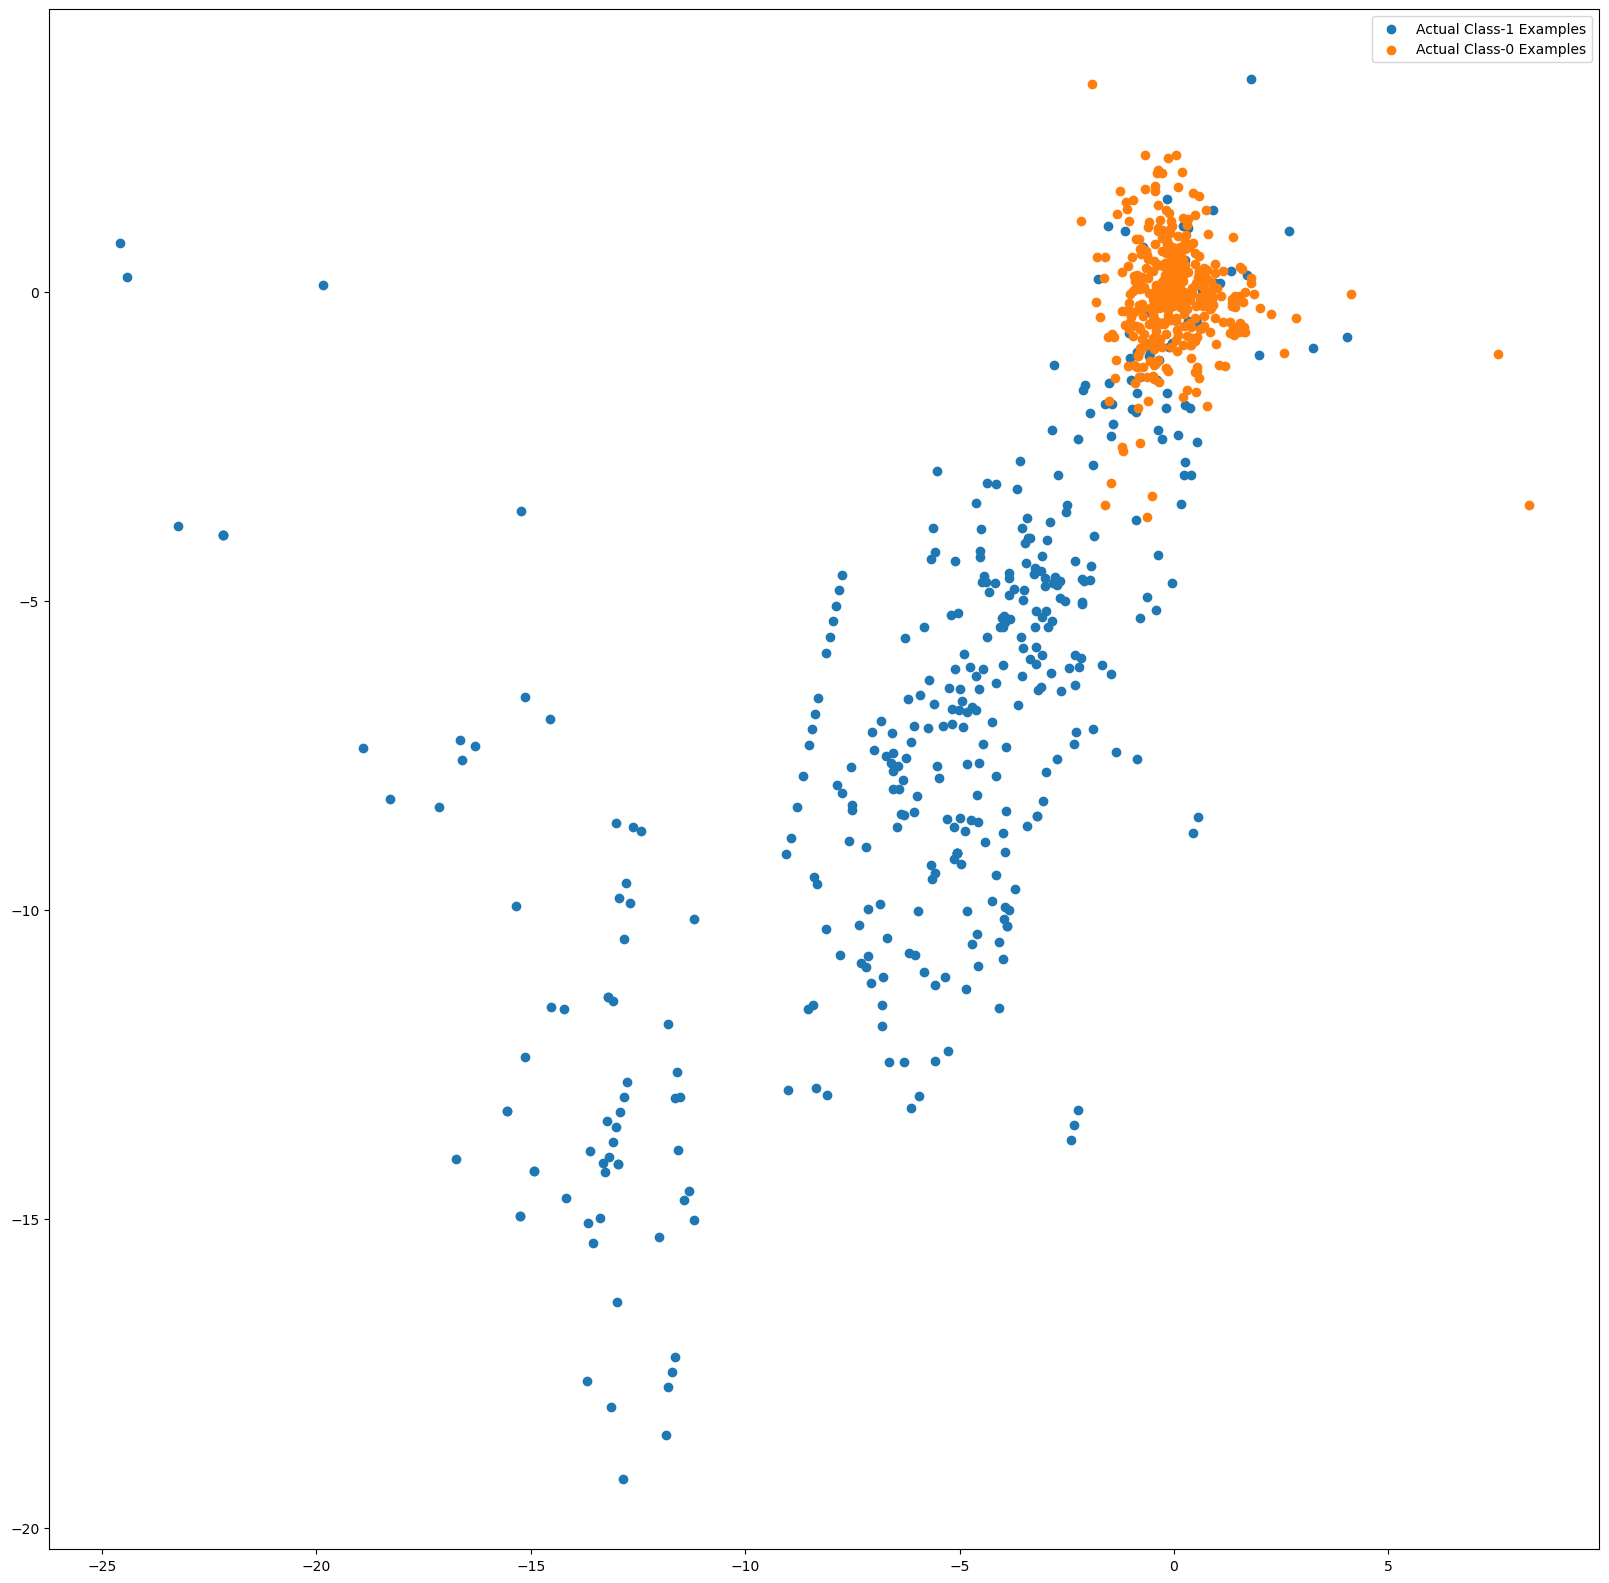

In [43]:
var_imp = []
for i in clf.feature_importances_:
    var_imp.append(i)
print('Top var =', var_imp.index(np.sort(clf.feature_importances_)[-1])+1)
print('2nd Top var =', var_imp.index(np.sort(clf.feature_importances_)[-2])+1)
print('3rd Top var =', var_imp.index(np.sort(clf.feature_importances_)[-3])+1)

# Variable on Index-16 and Index-13 seems to be the top 2 variables
top_var_index = var_imp.index(np.sort(clf.feature_importances_)[-1])
second_top_var_index = var_imp.index(np.sort(clf.feature_importances_)[-2])

X_train_1 = X_train.to_numpy()[np.where(y_train==1.0)]
X_train_0 = X_train.to_numpy()[np.where(y_train==0.0)]

np.random.shuffle(X_train_0)

import matplotlib.pyplot as plt
%matplotlib inline
plt.rcParams['figure.figsize'] = [20, 20]

plt.scatter(X_train_1[:, top_var_index], X_train_1[:, second_top_var_index], label='Actual Class-1 Examples')
plt.scatter(X_train_0[:X_train_1.shape[0], top_var_index], X_train_0[:X_train_1.shape[0], second_top_var_index],
            label='Actual Class-0 Examples')
plt.legend()

### So, as per the features importance given above, `V10`, `V14`, and `V7` are the top three features that help us to understand the dataset.

## Model building with balancing Classes

##### Perform class balancing with :
- Random Oversampling
- SMOTE
- ADASYN

### Again, We will explore the data by building models like:
- Logistic Regression 
- KNN
- Decision Tree
- Random Forest
- XGBoost

## Model Building
- Build different models on the balanced dataset and see the result

### Class balancing with Random Oversampling

In [24]:
from imblearn import over_sampling

In [25]:
from imblearn.over_sampling import SMOTE, RandomOverSampler, ADASYN

In [26]:
from sklearn.model_selection import StratifiedKFold, GridSearchCV
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score

In [27]:
param_grid = {'C': [0.01, 0.1, 1, 10, 100]}

In [28]:
def evaluate_model_with_ros(model, param_grid, X, y, model_name):
    skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
    best_auc = 0
    best_params = None
    results = []

    for fold, (train_idx, val_idx) in enumerate(skf.split(X, y)):
        X_train_cv, X_val_cv = X.iloc[train_idx], X.iloc[val_idx]
        y_train_cv, y_val_cv = y.iloc[train_idx], y.iloc[val_idx]

        # Apply Random Oversampling
        ros = RandomOverSampler(random_state=42)
        X_train_bal, y_train_bal = ros.fit_resample(X_train_cv, y_train_cv)

        # Grid Search with 3-fold CV
        grid = GridSearchCV(model, param_grid, cv=3, scoring='roc_auc')
        grid.fit(X_train_bal, y_train_bal)

        y_val_pred_proba = grid.predict_proba(X_val_cv)[:, 1]
        auc = roc_auc_score(y_val_cv, y_val_pred_proba)

        results.append({'fold': fold + 1, 'roc_auc': auc, 'best_params': grid.best_params_})

        if auc > best_auc:
            best_auc = auc
            best_params = grid.best_params_
            best_model = grid.best_estimator_

    print(f"\n📊 {model_name} Results (Random Oversampling):")
    df = pd.DataFrame(results)
    print(df)
    print(f"🏆 Best ROC AUC: {best_auc:.4f}")
    print(f"✅ Optimal Hyperparameters: {best_params}")

    return model_name, best_auc, best_params


In [29]:
models_ros = [
    ("Logistic Regression", LogisticRegression(solver='liblinear'), {'C': [0.001, 0.01, 0.1, 1, 10, 100]}),
    ("KNN", KNeighborsClassifier(), {'n_neighbors': [3, 5, 7]}),
    ("Decision Tree", DecisionTreeClassifier(random_state=42), {'max_depth': [3, 5, 10, None]}),
    ("Random Forest", RandomForestClassifier(random_state=42), {'n_estimators': [50, 100], 'max_depth': [5, 10, None]}),
    ("XGBoost", XGBClassifier(use_label_encoder=False, eval_metric='logloss'), {'n_estimators': [50, 100], 'max_depth': [3, 5, 7]})
]

In [30]:
summary_results_ros = []

for name, model, params in models_ros:
    model_name, auc_score, best_params = evaluate_model_with_ros(model, params, X_train, y_train, name)
    summary_results_ros.append({'Model': model_name, 'ROC AUC': auc_score, 'Best Params': best_params})



📊 Logistic Regression Results (Random Oversampling):
   fold   roc_auc best_params
0     1  0.991023  {'C': 100}
1     2  0.980092  {'C': 100}
2     3  0.965087   {'C': 10}
3     4  0.995490  {'C': 100}
4     5  0.977339  {'C': 100}
🏆 Best ROC AUC: 0.9955
✅ Optimal Hyperparameters: {'C': 100}

📊 KNN Results (Random Oversampling):
   fold   roc_auc         best_params
0     1  0.922869  {'n_neighbors': 5}
1     2  0.904894  {'n_neighbors': 7}
2     3  0.892293  {'n_neighbors': 3}
3     4  0.923896  {'n_neighbors': 3}
4     5  0.923881  {'n_neighbors': 3}
🏆 Best ROC AUC: 0.9239
✅ Optimal Hyperparameters: {'n_neighbors': 3}

📊 Decision Tree Results (Random Oversampling):
   fold   roc_auc          best_params
0     1  0.833081  {'max_depth': None}
1     2  0.816302  {'max_depth': None}
2     3  0.854309  {'max_depth': None}
3     4  0.873198  {'max_depth': None}
4     5  0.847980  {'max_depth': None}
🏆 Best ROC AUC: 0.8732
✅ Optimal Hyperparameters: {'max_depth': None}

📊 Random Forest R

C:\Users\tshar\anaconda3\Lib\site-packages\xgboost\core.py:158: UserWarning: [11:30:44] WARNING: C:\buildkite-agent\builds\buildkite-windows-cpu-autoscaling-group-i-0c55ff5f71b100e98-1\xgboost\xgboost-ci-windows\src\learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)
C:\Users\tshar\anaconda3\Lib\site-packages\xgboost\core.py:158: UserWarning: [11:30:48] WARNING: C:\buildkite-agent\builds\buildkite-windows-cpu-autoscaling-group-i-0c55ff5f71b100e98-1\xgboost\xgboost-ci-windows\src\learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)
C:\Users\tshar\anaconda3\Lib\site-packages\xgboost\core.py:158: UserWarning: [11:30:51] WARNING: C:\buildkite-agent\builds\buildkite-windows-cpu-autoscaling-group-i-0c55ff5f71b100e98-1\xgboost\xgboost-ci-windows\src\learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)
C:\Users\tshar\anaconda3\Lib\site-packages\


📊 XGBoost Results (Random Oversampling):
   fold   roc_auc                            best_params
0     1  0.987882  {'max_depth': 7, 'n_estimators': 100}
1     2  0.972053  {'max_depth': 7, 'n_estimators': 100}
2     3  0.962593  {'max_depth': 5, 'n_estimators': 100}
3     4  0.989352  {'max_depth': 5, 'n_estimators': 100}
4     5  0.972649  {'max_depth': 5, 'n_estimators': 100}
🏆 Best ROC AUC: 0.9894
✅ Optimal Hyperparameters: {'max_depth': 5, 'n_estimators': 100}


In [31]:
summary_df_ros = pd.DataFrame(summary_results_ros)
print("\n🔚 Final Comparison on Random Oversampled Data:")
print(summary_df_ros.sort_values(by="ROC AUC", ascending=False).reset_index(drop=True))



🔚 Final Comparison on Random Oversampled Data:
                 Model   ROC AUC                              Best Params
0  Logistic Regression  0.995490                               {'C': 100}
1              XGBoost  0.989352    {'max_depth': 5, 'n_estimators': 100}
2        Random Forest  0.954949  {'max_depth': None, 'n_estimators': 50}
3                  KNN  0.923896                       {'n_neighbors': 3}
4        Decision Tree  0.873198                      {'max_depth': None}


### Class balancing with SMOTE

#### Print the class distribution after applying SMOTE 

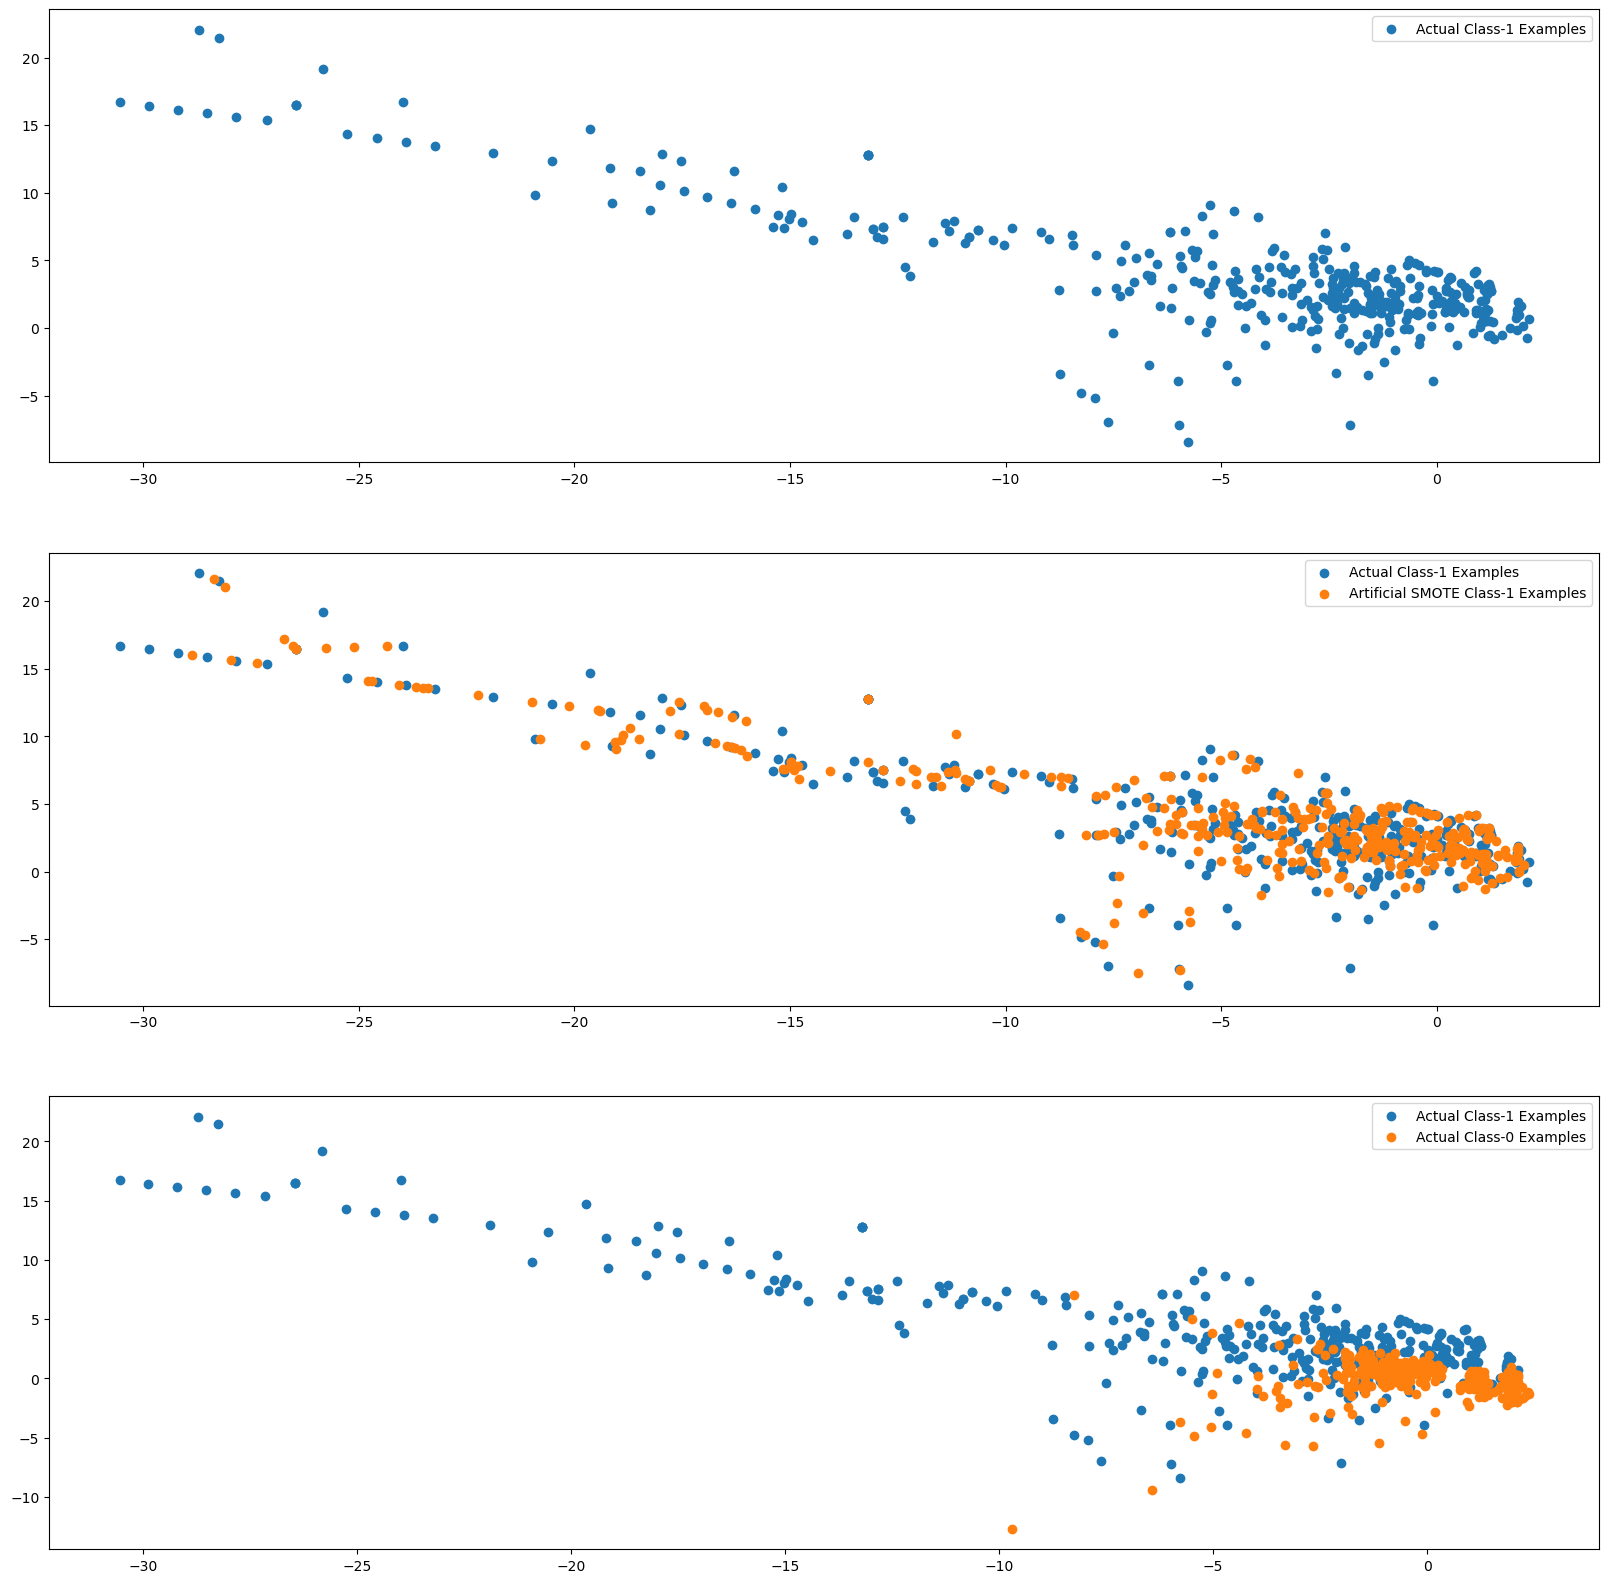

In [32]:
import warnings
warnings.filterwarnings("ignore")


sm = over_sampling.SMOTE(random_state=0)
X_train_smote, y_train_smote = sm.fit_resample(X_train, y_train)
# Artificial minority samples and corresponding minority labels from SMOTE are appended
# below X_train and y_train respectively
# So to exclusively get the artificial minority samples from SMOTE, we do
X_train_smote_1 = X_train_smote[X_train.shape[0]:]

X_train_1 = X_train.to_numpy()[np.where(y_train==1.0)]
X_train_0 = X_train.to_numpy()[np.where(y_train==0.0)]


plt.rcParams['figure.figsize'] = [20, 20]
fig = plt.figure()

plt.subplot(3, 1, 1)
plt.scatter(X_train_1[:, 0], X_train_1[:, 1], label='Actual Class-1 Examples')
plt.legend()

X_smote_np = X_train_smote_1.to_numpy()

plt.subplot(3, 1, 2)
plt.scatter(X_train_1[:, 0], X_train_1[:, 1], label='Actual Class-1 Examples')
plt.scatter(X_smote_np[:X_train_1.shape[0], 0], X_smote_np[:X_train_1.shape[0], 1],
            label='Artificial SMOTE Class-1 Examples')
plt.legend()

plt.subplot(3, 1, 3)
plt.scatter(X_train_1[:, 0], X_train_1[:, 1], label='Actual Class-1 Examples')
plt.scatter(X_train_0[:X_train_1.shape[0], 0], X_train_0[:X_train_1.shape[0], 1], label='Actual Class-0 Examples')
plt.legend()

In [33]:
def evaluate_model_with_smote(model, param_grid, X, y, model_name):
    skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
    best_auc = 0
    best_params = None
    results = []

    for fold, (train_idx, val_idx) in enumerate(skf.split(X, y)):
        X_train_cv, X_val_cv = X.iloc[train_idx], X.iloc[val_idx]
        y_train_cv, y_val_cv = y.iloc[train_idx], y.iloc[val_idx]

        # Apply SMOTE
        sm = SMOTE(random_state=42)
        X_train_bal, y_train_bal = sm.fit_resample(X_train_cv, y_train_cv)

        # Grid Search
        grid = GridSearchCV(model, param_grid, cv=3, scoring='roc_auc')
        grid.fit(X_train_bal, y_train_bal)

        y_val_pred_proba = grid.predict_proba(X_val_cv)[:, 1]
        auc = roc_auc_score(y_val_cv, y_val_pred_proba)

        results.append({'fold': fold + 1, 'roc_auc': auc, 'best_params': grid.best_params_})

        if auc > best_auc:
            best_auc = auc
            best_params = grid.best_params_
            best_model = grid.best_estimator_

    print(f"\n📊 {model_name} Results:")
    df = pd.DataFrame(results)
    print(df)
    print(f"🏆 Best ROC AUC: {best_auc:.4f}")
    print(f"✅ Optimal Hyperparameters: {best_params}")
    
    return model_name, best_auc, best_params


##### Build models on other algorithms to see the better performing on SMOTE

In [34]:
models = [
    ("Logistic Regression", LogisticRegression(solver='liblinear'), {'C': [0.001, 0.01, 0.1, 1, 10, 100]}),
    ("KNN", KNeighborsClassifier(), {'n_neighbors': [3, 5, 7]}),
    ("Decision Tree", DecisionTreeClassifier(random_state=42), {'max_depth': [3, 5, 10, None]}),
    ("Random Forest", RandomForestClassifier(random_state=42), {'n_estimators': [50, 100], 'max_depth': [5, 10, None]}),
    ("XGBoost", XGBClassifier(use_label_encoder=False, eval_metric='logloss'), {'n_estimators': [50, 100], 'max_depth': [3, 5, 7]})
]

In [35]:
summary_results = []

for name, model, params in models:
    model_name, auc_score, best_params = evaluate_model_with_smote(model, params, X_train, y_train, name)
    summary_results.append({'Model': model_name, 'ROC AUC': auc_score, 'Best Params': best_params})



📊 Logistic Regression Results:
   fold   roc_auc best_params
0     1  0.991409  {'C': 100}
1     2  0.978619  {'C': 100}
2     3  0.957791  {'C': 100}
3     4  0.994571  {'C': 100}
4     5  0.977127  {'C': 100}
🏆 Best ROC AUC: 0.9946
✅ Optimal Hyperparameters: {'C': 100}

📊 KNN Results:
   fold   roc_auc         best_params
0     1  0.935297  {'n_neighbors': 7}
1     2  0.910882  {'n_neighbors': 7}
2     3  0.910851  {'n_neighbors': 7}
3     4  0.961546  {'n_neighbors': 7}
4     5  0.929874  {'n_neighbors': 7}
🏆 Best ROC AUC: 0.9615
✅ Optimal Hyperparameters: {'n_neighbors': 7}

📊 Decision Tree Results:
   fold   roc_auc          best_params
0     1  0.876952  {'max_depth': None}
1     2  0.834575  {'max_depth': None}
2     3  0.872439  {'max_depth': None}
3     4  0.903975  {'max_depth': None}
4     5  0.891372  {'max_depth': None}
🏆 Best ROC AUC: 0.9040
✅ Optimal Hyperparameters: {'max_depth': None}

📊 Random Forest Results:
   fold   roc_auc                               best_param

In [36]:
summary_df = pd.DataFrame(summary_results)
print("\n🔚 Final Comparison of All Models:")
print(summary_df.sort_values(by="ROC AUC", ascending=False).reset_index(drop=True))



🔚 Final Comparison of All Models:
                 Model   ROC AUC                               Best Params
0  Logistic Regression  0.994571                                {'C': 100}
1              XGBoost  0.991707     {'max_depth': 7, 'n_estimators': 100}
2        Random Forest  0.983155  {'max_depth': None, 'n_estimators': 100}
3                  KNN  0.961546                        {'n_neighbors': 7}
4        Decision Tree  0.903975                       {'max_depth': None}


### Class balancing with ADASYN

#### Print the class distribution after applying ADASYN

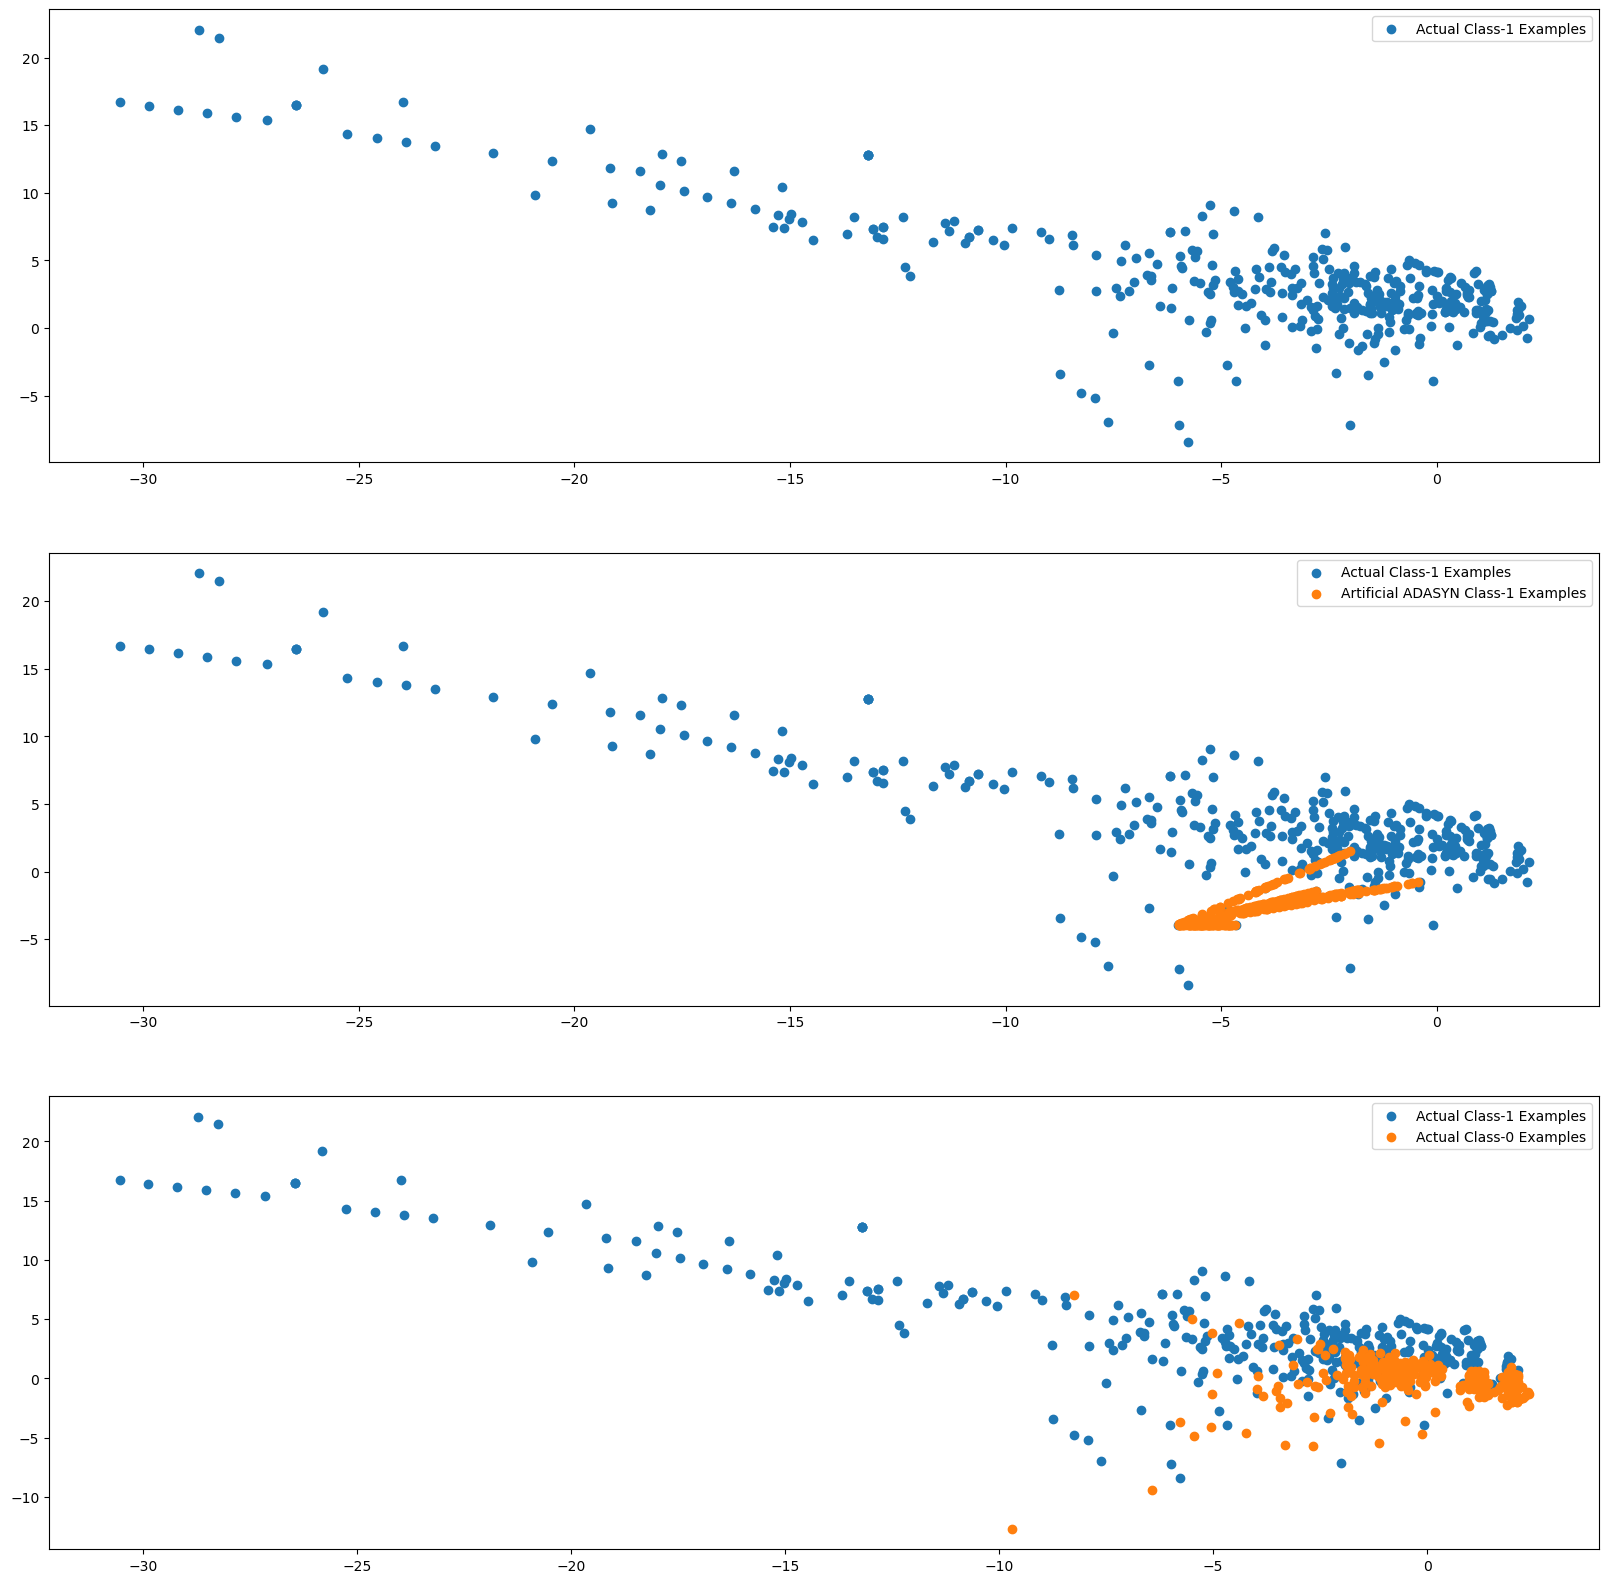

In [37]:
import warnings
warnings.filterwarnings("ignore")

from imblearn import over_sampling

ada = over_sampling.ADASYN(random_state=0)
X_train_adasyn, y_train_adasyn = ada.fit_resample(X_train, y_train)
# Artificial minority samples and corresponding minority labels from ADASYN are appended
# below X_train and y_train respectively
# So to exclusively get the artificial minority samples from ADASYN, we do
X_train_adasyn_1 = X_train_adasyn[X_train.shape[0]:]

X_train_1 = X_train.to_numpy()[np.where(y_train==1.0)]
X_train_0 = X_train.to_numpy()[np.where(y_train==0.0)]



import matplotlib.pyplot as plt
%matplotlib inline
plt.rcParams['figure.figsize'] = [20, 20]
fig = plt.figure()

plt.subplot(3, 1, 1)
plt.scatter(X_train_1[:, 0], X_train_1[:, 1], label='Actual Class-1 Examples')
plt.legend()

X_adasyn_np = X_train_adasyn_1.to_numpy()

plt.subplot(3, 1, 2)
plt.scatter(X_train_1[:, 0], X_train_1[:, 1], label='Actual Class-1 Examples')
plt.scatter(X_adasyn_np[:X_train_1.shape[0], 0], X_adasyn_np[:X_train_1.shape[0], 1],
            label='Artificial ADASYN Class-1 Examples')
plt.legend()

plt.subplot(3, 1, 3)
plt.scatter(X_train_1[:, 0], X_train_1[:, 1], label='Actual Class-1 Examples')
plt.scatter(X_train_0[:X_train_1.shape[0], 0], X_train_0[:X_train_1.shape[0], 1], label='Actual Class-0 Examples')
plt.legend()

In [38]:
def evaluate_model_with_adasyn(model, param_grid, X, y, model_name):
    skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
    best_auc = 0
    best_params = None
    results = []

    for fold, (train_idx, val_idx) in enumerate(skf.split(X, y)):
        X_train_cv, X_val_cv = X.iloc[train_idx], X.iloc[val_idx]
        y_train_cv, y_val_cv = y.iloc[train_idx], y.iloc[val_idx]

        # Apply ADASYN
        adasyn = ADASYN(random_state=42)
        X_train_bal, y_train_bal = adasyn.fit_resample(X_train_cv, y_train_cv)

        # Grid Search with 3-fold CV
        grid = GridSearchCV(model, param_grid, cv=3, scoring='roc_auc')
        grid.fit(X_train_bal, y_train_bal)

        y_val_pred_proba = grid.predict_proba(X_val_cv)[:, 1]
        auc = roc_auc_score(y_val_cv, y_val_pred_proba)

        results.append({'fold': fold + 1, 'roc_auc': auc, 'best_params': grid.best_params_})

        if auc > best_auc:
            best_auc = auc
            best_params = grid.best_params_
            best_model = grid.best_estimator_

    print(f"\n📊 {model_name} Results:")
    df = pd.DataFrame(results)
    print(df)
    print(f"🏆 Best ROC AUC: {best_auc:.4f}")
    print(f"✅ Optimal Hyperparameters: {best_params}")

    return model_name, best_auc, best_params


In [39]:
models = [
    ("Logistic Regression", LogisticRegression(solver='liblinear'), {'C': [0.001, 0.01, 0.1, 1, 10, 100]}),
    ("KNN", KNeighborsClassifier(), {'n_neighbors': [3, 5, 7]}),
    ("Decision Tree", DecisionTreeClassifier(random_state=42), {'max_depth': [3, 5, 10, None]}),
    ("Random Forest", RandomForestClassifier(random_state=42), {'n_estimators': [50, 100], 'max_depth': [5, 10, None]}),
    ("XGBoost", XGBClassifier(use_label_encoder=False, eval_metric='logloss'), {'n_estimators': [50, 100], 'max_depth': [3, 5, 7]})
]

In [40]:
summary_results_adasyn = []

for name, model, params in models:
    model_name, auc_score, best_params = evaluate_model_with_adasyn(model, params, X_train, y_train, name)
    summary_results_adasyn.append({'Model': model_name, 'ROC AUC': auc_score, 'Best Params': best_params})



📊 Logistic Regression Results:
   fold   roc_auc  best_params
0     1  0.992125  {'C': 0.01}
1     2  0.979951    {'C': 10}
2     3  0.958260    {'C': 10}
3     4  0.988111  {'C': 0.01}
4     5  0.976566   {'C': 0.1}
🏆 Best ROC AUC: 0.9921
✅ Optimal Hyperparameters: {'C': 0.01}

📊 KNN Results:
   fold   roc_auc         best_params
0     1  0.935296  {'n_neighbors': 7}
1     2  0.910867  {'n_neighbors': 7}
2     3  0.910848  {'n_neighbors': 7}
3     4  0.961546  {'n_neighbors': 7}
4     5  0.929864  {'n_neighbors': 7}
🏆 Best ROC AUC: 0.9615
✅ Optimal Hyperparameters: {'n_neighbors': 7}

📊 Decision Tree Results:
   fold   roc_auc        best_params
0     1  0.934066  {'max_depth': 10}
1     2  0.935229   {'max_depth': 5}
2     3  0.915385  {'max_depth': 10}
3     4  0.976391   {'max_depth': 5}
4     5  0.972607   {'max_depth': 5}
🏆 Best ROC AUC: 0.9764
✅ Optimal Hyperparameters: {'max_depth': 5}

📊 Random Forest Results:
   fold   roc_auc                               best_params
0     

In [41]:
summary_df_adasyn = pd.DataFrame(summary_results_adasyn)
print("\n🔚 Final Comparison on ADASYN-resampled Data:")
print(summary_df_adasyn.sort_values(by="ROC AUC", ascending=False).reset_index(drop=True))


🔚 Final Comparison on ADASYN-resampled Data:
                 Model   ROC AUC                               Best Params
0        Random Forest  0.995401  {'max_depth': None, 'n_estimators': 100}
1  Logistic Regression  0.992125                               {'C': 0.01}
2              XGBoost  0.990103     {'max_depth': 7, 'n_estimators': 100}
3        Decision Tree  0.976391                          {'max_depth': 5}
4                  KNN  0.961546                        {'n_neighbors': 7}


### Select the oversampling method which shows the best result on a model
- Apply the best hyperparameter on the model
- Predict on the test dataset

#### Best ROC AUC Score
Oversampling Method: ADASYN

Best Model: Random Forest

ROC AUC: 0.995401

Best Hyperparameters: {'max_depth': None, 'n_estimators': 100}


#### Prediction on the test dataset

In [49]:
# Step 1: Perform ADASYN on training data
adasyn = ADASYN(random_state=42)
X_train_ada, y_train_ada = adasyn.fit_resample(X_train, y_train)

# Step 2: Initialize Random Forest with best hyperparameters
clf = RandomForestClassifier(n_estimators=100, max_depth=None, random_state=42)

# Step 3: Train the model on ADASYN-balanced data
clf.fit(X_train_ada, y_train_ada)

# Step 4: Predict probabilities on the test set
y_pred_proba = clf.predict_proba(X_test)[:, 1]

# Step 5: Evaluate using ROC AUC
roc_auc = roc_auc_score(y_test, y_pred_proba)
print(f"ROC AUC on Test Data (ADASYN + Random Forest): {roc_auc:.6f}")

ROC AUC on Test Data (ADASYN + Random Forest): 0.958803


### Print the important features of the best model to understand the dataset

Top var = 4
2nd Top var = 14
3rd Top var = 17


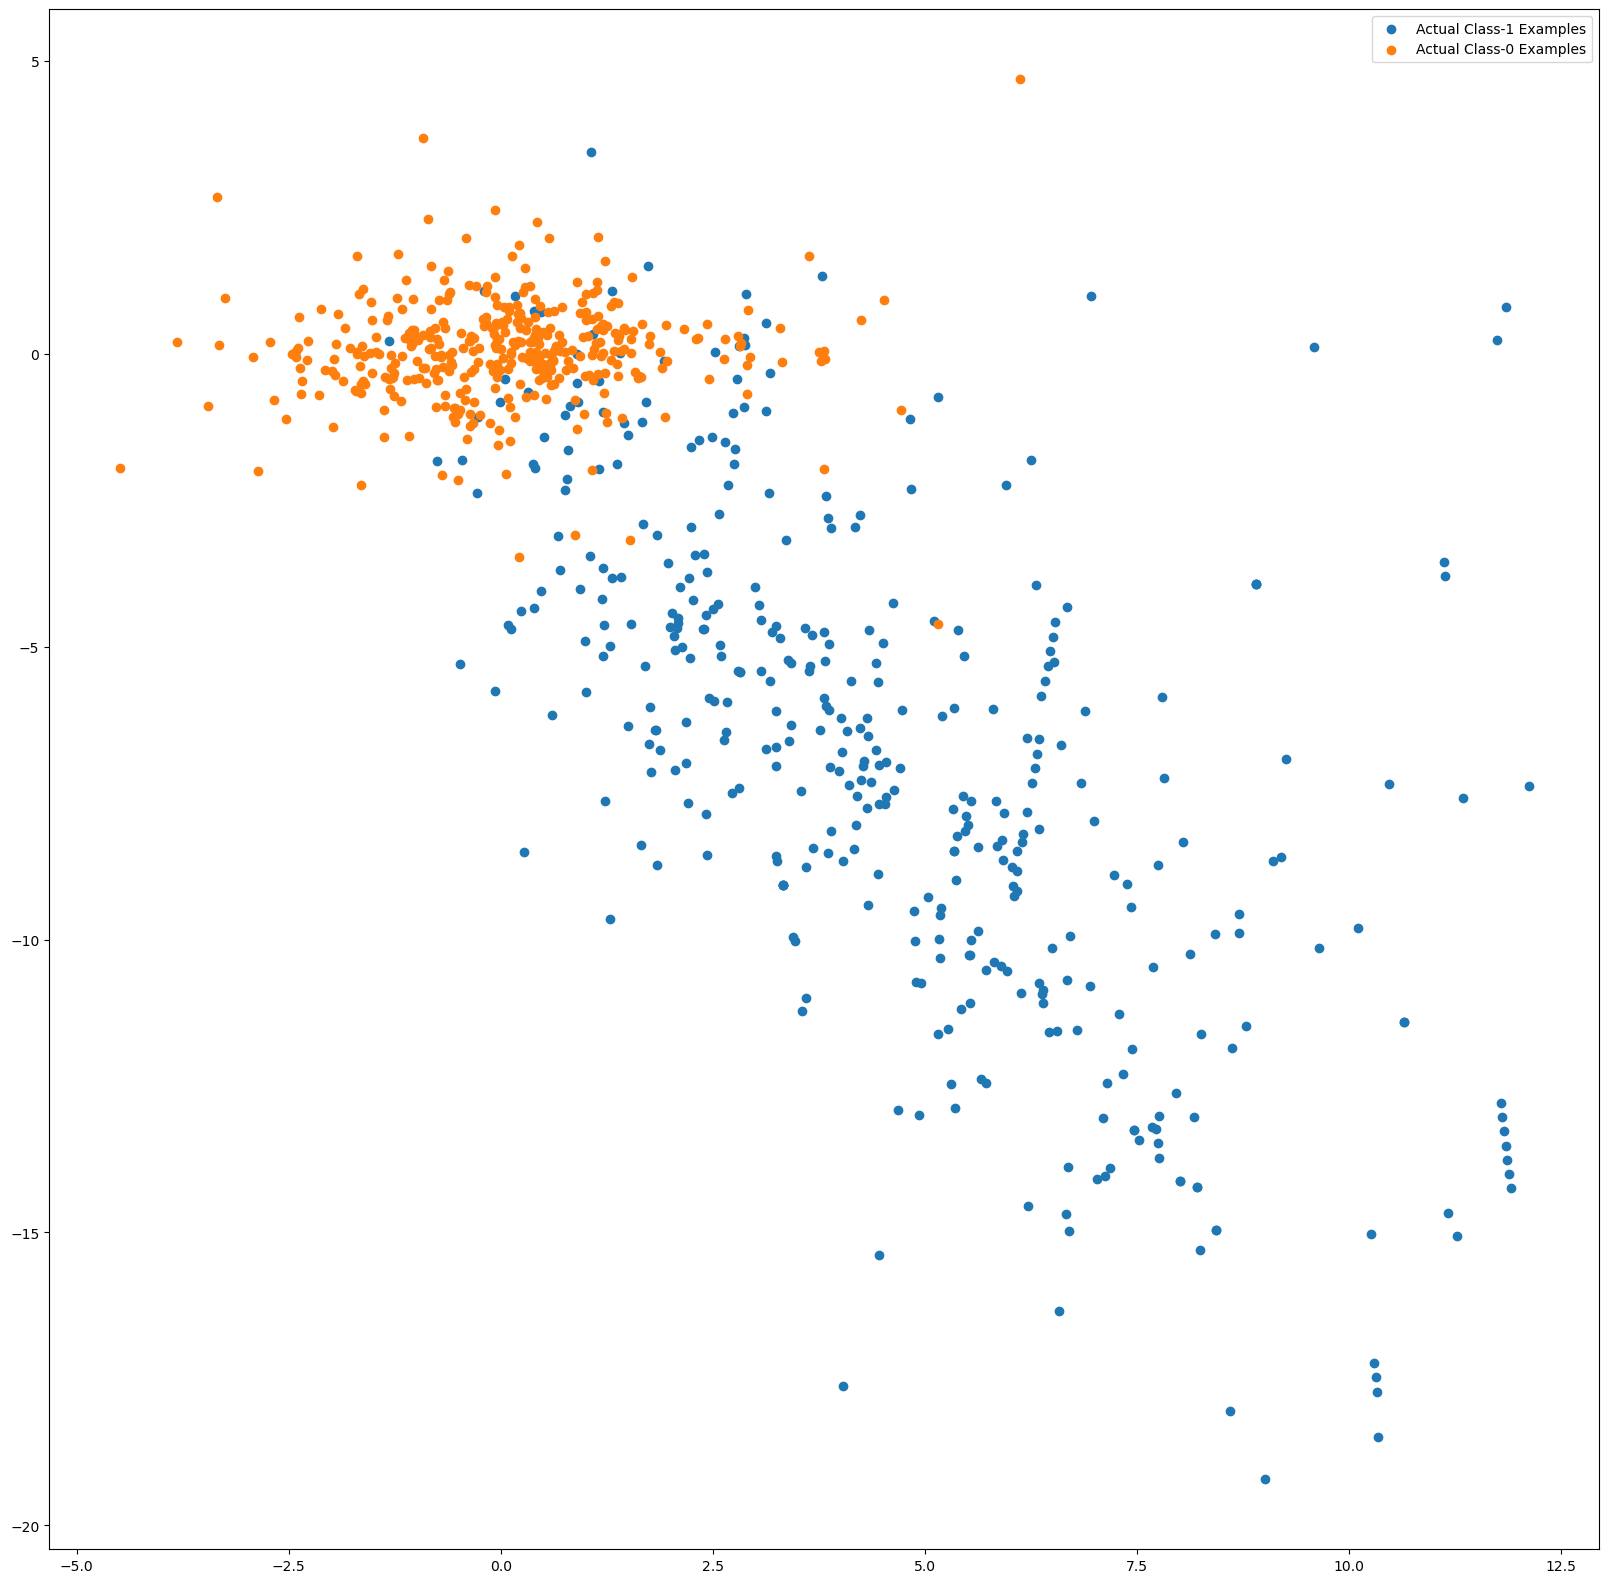

In [50]:
var_imp = []
for i in clf.feature_importances_:
    var_imp.append(i)
print('Top var =', var_imp.index(np.sort(clf.feature_importances_)[-1])+1)
print('2nd Top var =', var_imp.index(np.sort(clf.feature_importances_)[-2])+1)
print('3rd Top var =', var_imp.index(np.sort(clf.feature_importances_)[-3])+1)

# Variable on Index-13 and Index-9 seems to be the top 2 variables
top_var_index = var_imp.index(np.sort(clf.feature_importances_)[-1])
second_top_var_index = var_imp.index(np.sort(clf.feature_importances_)[-2])

X_train_1 = X_train.to_numpy()[np.where(y_train==1.0)]
X_train_0 = X_train.to_numpy()[np.where(y_train==0.0)]

np.random.shuffle(X_train_0)

import matplotlib.pyplot as plt
%matplotlib inline
plt.rcParams['figure.figsize'] = [20, 20]

plt.scatter(X_train_1[:, top_var_index], X_train_1[:, second_top_var_index], label='Actual Class-1 Examples')
plt.scatter(X_train_0[:X_train_1.shape[0], top_var_index], X_train_0[:X_train_1.shape[0], second_top_var_index],
            label='Actual Class-0 Examples')
plt.legend()

### So, as per the features importance given above, `V4`, `V14`, and `V17` are the top three features that help us to understand the dataset.

In [56]:
# Predict probabilities on the test set
y_test_pred_proba = clf.predict_proba(X_test)[:, 1]

# Print AUC
print('Test AUC =', metrics.roc_auc_score(y_test, y_test_pred_proba))

# Compute FPR, TPR, and thresholds for the test set
fpr, tpr, thresholds = metrics.roc_curve(y_test, y_test_pred_proba)

# Find best threshold (where TPR - FPR is maximized)
threshold = thresholds[np.argmax(tpr - fpr)]
print("Best Threshold =", threshold)

Test AUC = 0.9588033352761476
Best Threshold = 0.04


### Test AUC = 0.9588
This is a very good ROC AUC score on the test set.

It means the model is very effective at ranking fraud vs. non-fraud transactions, with ~95.9% probability that a randomly chosen fraud is ranked higher than a randomly chosen non-fraud.

So, even though it doesn't perfectly classify (AUC < 1), it's strong at distinguishing between the classes.

### Best Threshold = 0.04

This part is super interesting. Here's what it tells us:

✅ Interpretation:
The optimal threshold based on ROC curve is 0.04, which is very low.

This means:
"If the predicted probability of fraud is at least 4%, classify it as fraud."

The model is being conservative in assigning high probabilities to the positive class (fraud).

Fraud is typically rare (imbalanced dataset), and models often produce lower probabilities for the minority class.

So if you stick to the default threshold of 0.5, you'd miss a lot of fraud cases (high false negatives).

✅ What this threshold does:
Increases recall (TPR): You're catching more fraudulent cases.

May increase FPR: Some legitimate transactions might be wrongly flagged.

It's all about the trade-off: if catching more fraud is a priority, this threshold helps.

## In our problem statement, to save banks from high-value fraudulent transactions, we need to focus on a high recall to detect actual fraudulent transactions. So, this is a good model.

In [59]:
from sklearn.metrics import classification_report, confusion_matrix
y_test_pred_custom = (y_test_pred_proba >= 0.04).astype(int)
print(confusion_matrix(y_test, y_test_pred_custom))
print(classification_report(y_test, y_test_pred_custom))


[[55951   913]
 [    8    90]]
              precision    recall  f1-score   support

           0       1.00      0.98      0.99     56864
           1       0.09      0.92      0.16        98

    accuracy                           0.98     56962
   macro avg       0.54      0.95      0.58     56962
weighted avg       1.00      0.98      0.99     56962

